In [ ]:
# Import library wajib
import pandas as pd

from sklearn.preprocessing import StandardScaler

%matplotlib inline
df = pd.read_csv('data/data_sumatera.csv')
df

,time,latitude,longitude,number,step,surface,valid_time,u10,v10,t2m,sp
0,2026-02-01 00:00:00,6.0,95.00,0,0 days,0.0,2026-02-01 00:00:00,-5.624283,-2.132980,300.81300,101168.440
1,2026-02-01 00:00:00,6.0,95.25,0,0 days,0.0,2026-02-01 00:00:00,-5.433853,-1.257980,300.86182,101186.440
2,2026-02-01 00:00:00,6.0,95.50,0,0 days,0.0,2026-02-01 00:00:00,-4.668228,-0.316574,300.78564,101233.440
3,2026-02-01 00:00:00,6.0,95.75,0,0 days,0.0,2026-02-01 00:00:00,-4.273697,-0.208176,300.78760,101297.440
4,2026-02-01 00:00:00,6.0,96.00,0,0 days,0.0,2026-02-01 00:00:00,-4.218033,-0.741379,300.88525,101296.440
...,...,...,...,...,...,...,...,...,...,...,...
1547611,2026-02-28 23:00:00,-6.0,105.50,0,0 days,0.0,2026-02-28 23:00:00,3.876679,-0.784698,301.07520,100828.625
1547612,2026-02-28 23:00:00,-6.0,105.75,0,0 days,0.0,2026-02-28 23:00:00,3.367889,0.400848,300.93652,100424.625
1547613,2026-02-28 23:00:00,-6.0,106.00,0,0 days,0.0,2026-02-28 23:00:00,1.286835,0.784637,299.36230,99891.625
1547614,2026-02-28 23:00:00,-6.0,106.25,0,0 days,0.0,2026-02-28 23:00:00,-0.023712,0.557098,299.17870,100706.625


### Mengambil fitur yang diperlukan

In [ ]:
fitur_cuaca = ['t2m', 'sp', 'u10', 'v10']
kolom_penting = ['latitude', 'longitude'] + fitur_cuaca

df_clean = df[kolom_penting].dropna().copy()
df_clean['t2m_celcius'] = df_clean['t2m'] - 273.15

df_clean.head()

,latitude,longitude,t2m,sp,u10,v10,t2m_celcius
0,6.0,95.00,300.81300,101168.44,-5.624283,-2.132980,27.66300
1,6.0,95.25,300.86182,101186.44,-5.433853,-1.257980,27.71182
2,6.0,95.50,300.78564,101233.44,-4.668228,-0.316574,27.63564
3,6.0,95.75,300.78760,101297.44,-4.273697,-0.208176,27.63760
4,6.0,96.00,300.88525,101296.44,-4.218033,-0.741379,27.73525


In [ ]:
df_clean.describe()

,latitude,longitude,t2m,sp,u10,v10,t2m_celcius
count,1.547616e+06,1.547616e+06,1.547616e+06,1.547616e+06,1.547616e+06,1.547616e+06,1.547616e+06
mean,0.000000e+00,1.007500e+02,2.997308e+02,1.000026e+05,1.023687e+00,-1.880231e+00,2.658080e+01
std,3.535535e+00,3.391166e+00,2.205738e+00,2.559975e+03,3.004307e+00,2.444503e+00,2.205738e+00
min,-6.000000e+00,9.500000e+01,2.849675e+02,8.220981e+04,-1.078789e+01,-1.095143e+01,1.181753e+01
25%,-3.000000e+00,9.775000e+01,2.989419e+02,1.005409e+05,-8.350639e-01,-3.431946e+00,2.579190e+01
50%,0.000000e+00,1.007500e+02,3.000183e+02,1.008819e+05,6.860352e-01,-1.474228e+00,2.686830e+01
75%,3.000000e+00,1.037500e+02,3.010054e+02,1.010843e+05,2.889298e+00,-1.898193e-01,2.785537e+01
max,6.000000e+00,1.065000e+02,3.105078e+02,1.026839e+05,1.157724e+01,1.006039e+01,3.735780e+01


In [ ]:
scaler = StandardScaler()
df_clean[fitur_cuaca] = scaler.fit_transform(df_clean[fitur_cuaca])
df_clean

,latitude,longitude,t2m,sp,u10,v10,t2m_celcius
0,6.0,95.00,0.490628,0.455413,-2.212814,-0.103395,27.66300
1,6.0,95.25,0.512762,0.462444,-2.149428,0.254551,27.71182
2,6.0,95.50,0.478224,0.480804,-1.894586,0.639663,27.63564
3,6.0,95.75,0.479113,0.505804,-1.763264,0.684006,27.63760
4,6.0,96.00,0.523384,0.505413,-1.744736,0.465883,27.73525
...,...,...,...,...,...,...,...
1547611,-6.0,105.50,0.609500,0.322671,0.949634,0.448162,27.92520
1547612,-6.0,105.75,0.546628,0.164857,0.780281,0.933147,27.78652
1547613,-6.0,106.00,-0.167066,-0.043348,0.087590,1.090148,26.21230
1547614,-6.0,106.25,-0.250303,0.275015,-0.348633,0.997066,26.02870


#### Arti Fitur yang diambil

<b/>time / valid_time</b>: Menunjukkan waktu pengamatan per jam. ini adalah urutan waktu dari tanggal 1 sampai 28 Februari 2026 <br>
<b>latitude & longitude:</b> Koordinat lokasi di Pulau Sumatera. Jarak antar titik (grid) 25 derajat atau sekitar 27-28 km. <br>
<b>u10(10m u-component of wind):</b> Kecepatan angin dari arah Barat ke Timur. <br>
<b>v10(10m v-component of wind):</b> Kecepatan angin dari arah Selatan ke Utara.<br>
<b>t2m(2m temperature):</b> Suhu udara di ketinggian 2 meter. Satuannya Kelvin.<br>
<b>sp(Surface pressure):</b> Tekanan udara di permukaan tanah.

          t2m        sp       u10       v10
t2m  1.000000  0.603350  0.176856 -0.083017
sp   0.603350  1.000000  0.104610 -0.236716
u10  0.176856  0.104610  1.000000  0.029069
v10 -0.083017 -0.236716  0.029069  1.000000


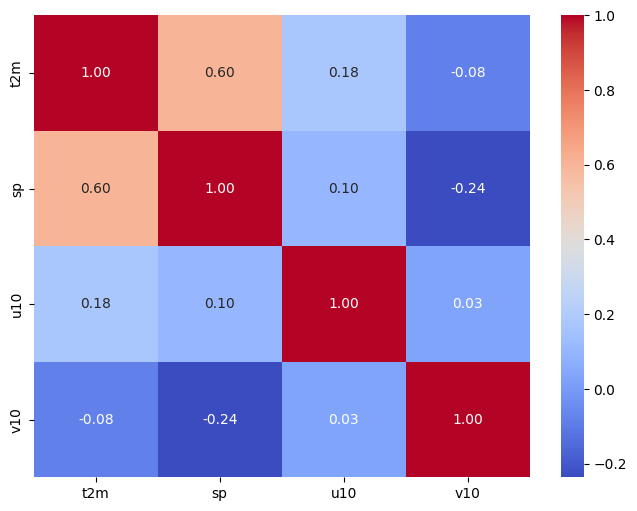

In [ ]:
korelasi = df_clean[['t2m', 'sp', 'u10', 'v10']].corr()
print(korelasi)

# Versi visual biar keren buat ditaruh di naskah jurnal (Bab EDA)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Berdasarkan hasil uji korelasi Pearson, ditemukan hubungan yang sangat kuat antara fitur Suhu Udara (t2m) dan Tekanan Permukaan (sp) dengan nilai korelasi sebesar 0.60. Tingginya korelasi ini secara fisis merepresentasikan efek topografi dan elevasi di kawasan Sumatera, di mana pergerakan dari dataran rendah menuju dataran tinggi akan diikuti oleh penurunan tekanan dan suhu secara simultan. Karakteristik data inilah yang menjadi pendorong utama (driver) bagi algoritma K-Means dalam membentuk klaster yang merepresentasikan batas-batas geografis dan orografis secara akurat.

#### Memilih Kluster Optimal

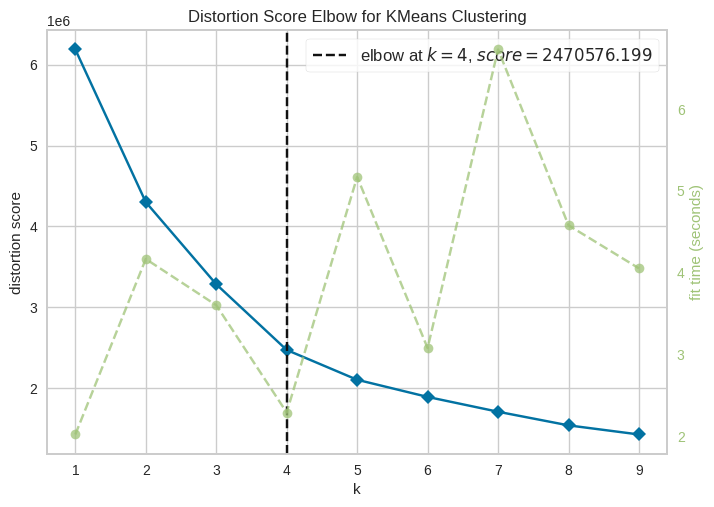

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

X = df_clean[fitur_cuaca]
kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1, 10), random_state=4)
visualizer.fit(X)
visualizer.show()

In [ ]:
k_optimal = 4
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_clean['cluster'] = kmeans_final.fit_predict(df_clean[fitur_cuaca])

In [ ]:
cluster_palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

cluster_counts = df_clean['cluster'].value_counts().sort_index()

HTTP Status Code: 200
Content-Type: application/zip
Download complete.
Attempting to extract ne_10m_admin_0_countries.zip to natural_earth_data...
Extraction complete.


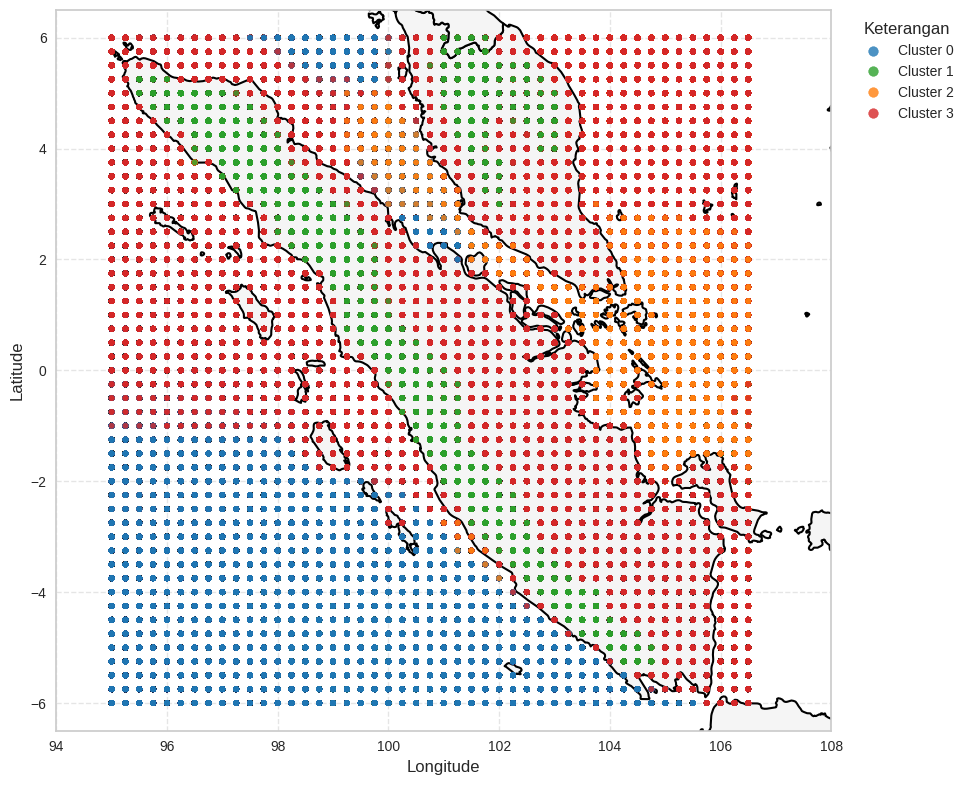

✅ Selesai! Cek gambar peta_sumatera_asli.png di foldermu.


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import os
import requests
import zipfile

natural_earth_url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"

zip_file_name = "ne_10m_admin_0_countries.zip"
shapefile_name = "ne_10m_admin_0_countries.shp"
extract_dir = "natural_earth_data"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
}

if os.path.exists(zip_file_name):
    print(f"Removing existing {zip_file_name} to force fresh download...")
    os.remove(zip_file_name)

if not os.path.exists(zip_file_name):
    print(f"Downloading {zip_file_name} from {natural_earth_url}...")
    response = requests.get(natural_earth_url, headers=headers)

    print(f"HTTP Status Code: {response.status_code}")
    print(f"Content-Type: {response.headers.get('Content-Type')}")

    if response.status_code == 200 and ('application/zip' in response.headers.get('Content-Type', '') or 'octet-stream' in response.headers.get('Content-Type', '')):
        with open(zip_file_name, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print("Error: The downloaded content is not a valid zip file or the request failed.")
        print("Response headers:", response.headers)
        print("Response content snippet (first 500 chars):")
        print(response.text[:500])
        raise Exception("Failed to download a valid Natural Earth data zip file.")

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir, exist_ok=True)

if not os.path.exists(os.path.join(extract_dir, shapefile_name)):
    print(f"Attempting to extract {zip_file_name} to {extract_dir}...")
    try:
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    except zipfile.BadZipFile as e:
        print(f"Error extracting zip file: {e}. The downloaded file '{zip_file_name}' might be corrupted.")
        if os.path.exists(zip_file_name):
            os.remove(zip_file_name)
            print(f"Removed corrupted {zip_file_name}.")
        raise

world = gpd.read_file(os.path.join(extract_dir, shapefile_name))

fig, ax = plt.subplots(figsize=(10, 12))

world.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1.5)

custom_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
new_cmap = colors.ListedColormap(custom_colors)


scatter = ax.scatter(df_clean['longitude'], df_clean['latitude'],
                     c=df_clean['cluster'], cmap=new_cmap,
                     s=15, alpha=0.8, zorder=5)

ax.set_xlim(94, 108)  # Batas Kiri - Kanan (Bujur/Longitude)
ax.set_ylim(-6.5, 6.5) # Batas Bawah - Atas (Lintang/Latitude)

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

handles, labels = scatter.legend_elements()
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']
plt.legend(handles, labels, title="Keterangan", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plt.savefig('peta_sumatera_asli.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Selesai! Cek gambar peta_sumatera_asli.png di foldermu.")

### Temuan Utama dari Analisis Data Eksploratori (EDA) Berdasarkan Kluster

1. **Kluster 0 (Laut/Pesisir)**: Ditandai dengan suhu tinggi dan tekanan udara sedang disertai angin kencang yang bertiup ke arah utara (u10), yang mengindikasikan wilayah dengan pengaruh maritim yang signifikan.
2. **Kluster 1 (Pegunungan)**: Menunjukkan suhu dan tekanan permukaan terendah, yang mencerminkan daerah pegunungan dengan ketinggian tinggi. Korelasi antara suhu dan tekanan tetap positif tetapi dipengaruhi oleh ketinggian.
3. **Kluster 2 (Dataran Rendah)**: Menunjukkan tekanan permukaan yang tinggi dan suhu yang stabil. Komponen angin lebih bervariasi dibandingkan dengan kluster maritim.
4. **Cluster 3 (Transisi)**: Mewakili daerah dengan profil cuaca menengah. Peta panas korelasi menunjukkan bahwa meskipun beberapa variabel seperti suhu dan tekanan umumnya saling terkait, pola angin (u10, v10) menunjukkan perilaku lokal yang berbeda di dalam setiap cluster.

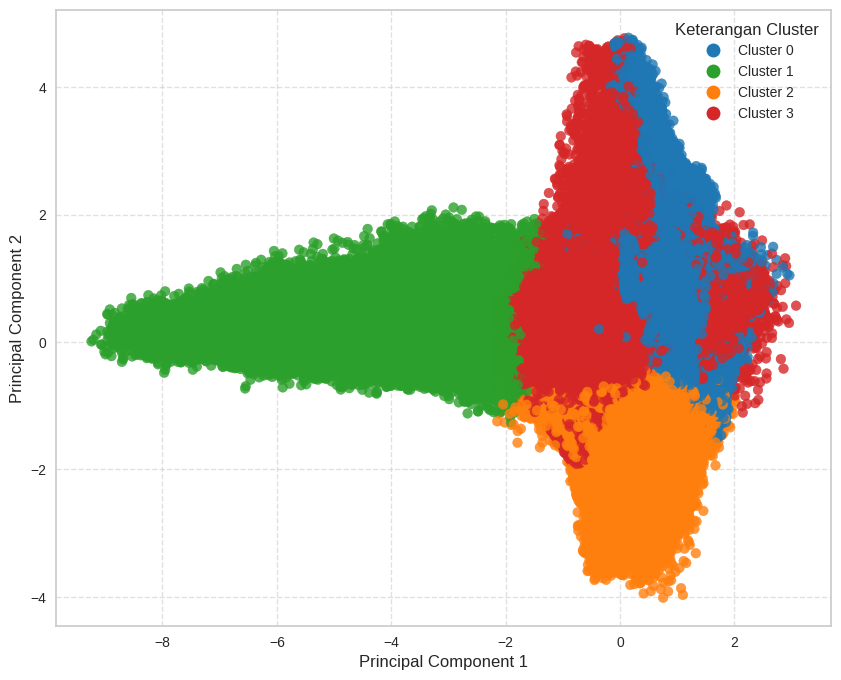

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as colors

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_clean[fitur_cuaca])

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=df_clean['cluster'],
    cmap=colors.ListedColormap(cluster_palette),
    alpha=0.8
)

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Create a legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
                     markerfacecolor=cluster_palette[i], markersize=10)
           for i in sorted(df_clean['cluster'].unique())]
plt.legend(handles=handles, title="Keterangan Cluster", loc="upper right", fontsize=10)

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
df_sample = df_clean.sample(frac=0.2, random_state=42)

X_sample = df_sample[fitur_cuaca]
labels_sample = df_sample['cluster']

score = silhouette_score(X_sample, labels_sample)

print(f'Silhouette Score for {k_optimal} clusters: {score:.4f}')

Silhouette Score for 4 clusters: 0.3078


#### mengembalikan nilai scaling seperti semula

In [ ]:
# Create a copy of df_clean to work with unscaled data
df_unscaled = df_clean.copy()

# Inverse transform the scaled weather features back to their original values
df_unscaled[fitur_cuaca] = scaler.inverse_transform(df_clean[fitur_cuaca])

print("✅ Weather features in 'df_unscaled' have been reverted to their original values.")
display(df_unscaled.head())

✅ Weather features in 'df_unscaled' have been reverted to their original values.


,latitude,longitude,t2m,sp,u10,v10,t2m_celcius,cluster
0,6.0,95.00,300.81300,101168.44,-5.624283,-2.132980,27.66300,2
1,6.0,95.25,300.86182,101186.44,-5.433853,-1.257980,27.71182,3
2,6.0,95.50,300.78564,101233.44,-4.668228,-0.316574,27.63564,3
3,6.0,95.75,300.78760,101297.44,-4.273697,-0.208176,27.63760,3
4,6.0,96.00,300.88525,101296.44,-4.218033,-0.741379,27.73525,3


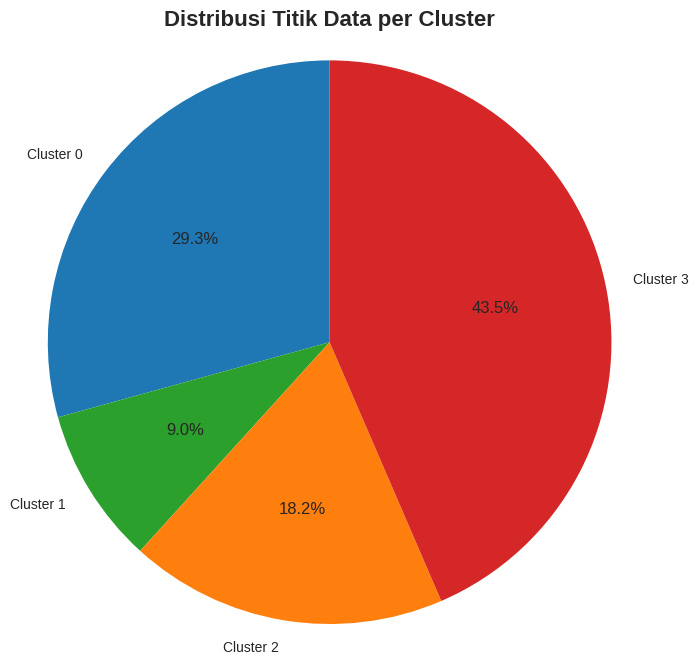

In [ ]:
import matplotlib.pyplot as plt

# 4 & 5. Re-generate the pie chart with consistent colors
plt.figure(figsize=(8, 8))
plt.pie(cluster_counts,
        labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%',
        startangle=90,
        colors=cluster_palette)

plt.title('Distribusi Titik Data per Cluster', fontsize=16, fontweight='bold')
plt.axis('equal')

plt.show()

CENTROID PADA 4 CLUSTER

In [ ]:
centroid = df_unscaled.groupby('cluster')[['t2m', 'sp', 'u10', 'v10', "t2m_celcius"]].mean()
centroid

,t2m,sp,u10,v10,t2m_celcius
cluster,,,,,
0,300.612852,100881.425357,4.505580,-2.727814,27.462852
1,295.097776,93058.054614,0.021770,-0.218354,21.947776
2,299.501579,101021.760722,-1.973393,-5.131562,26.351579
3,300.188315,100416.299764,0.140966,-0.291224,27.038315


#### Visualisasi Box Plot

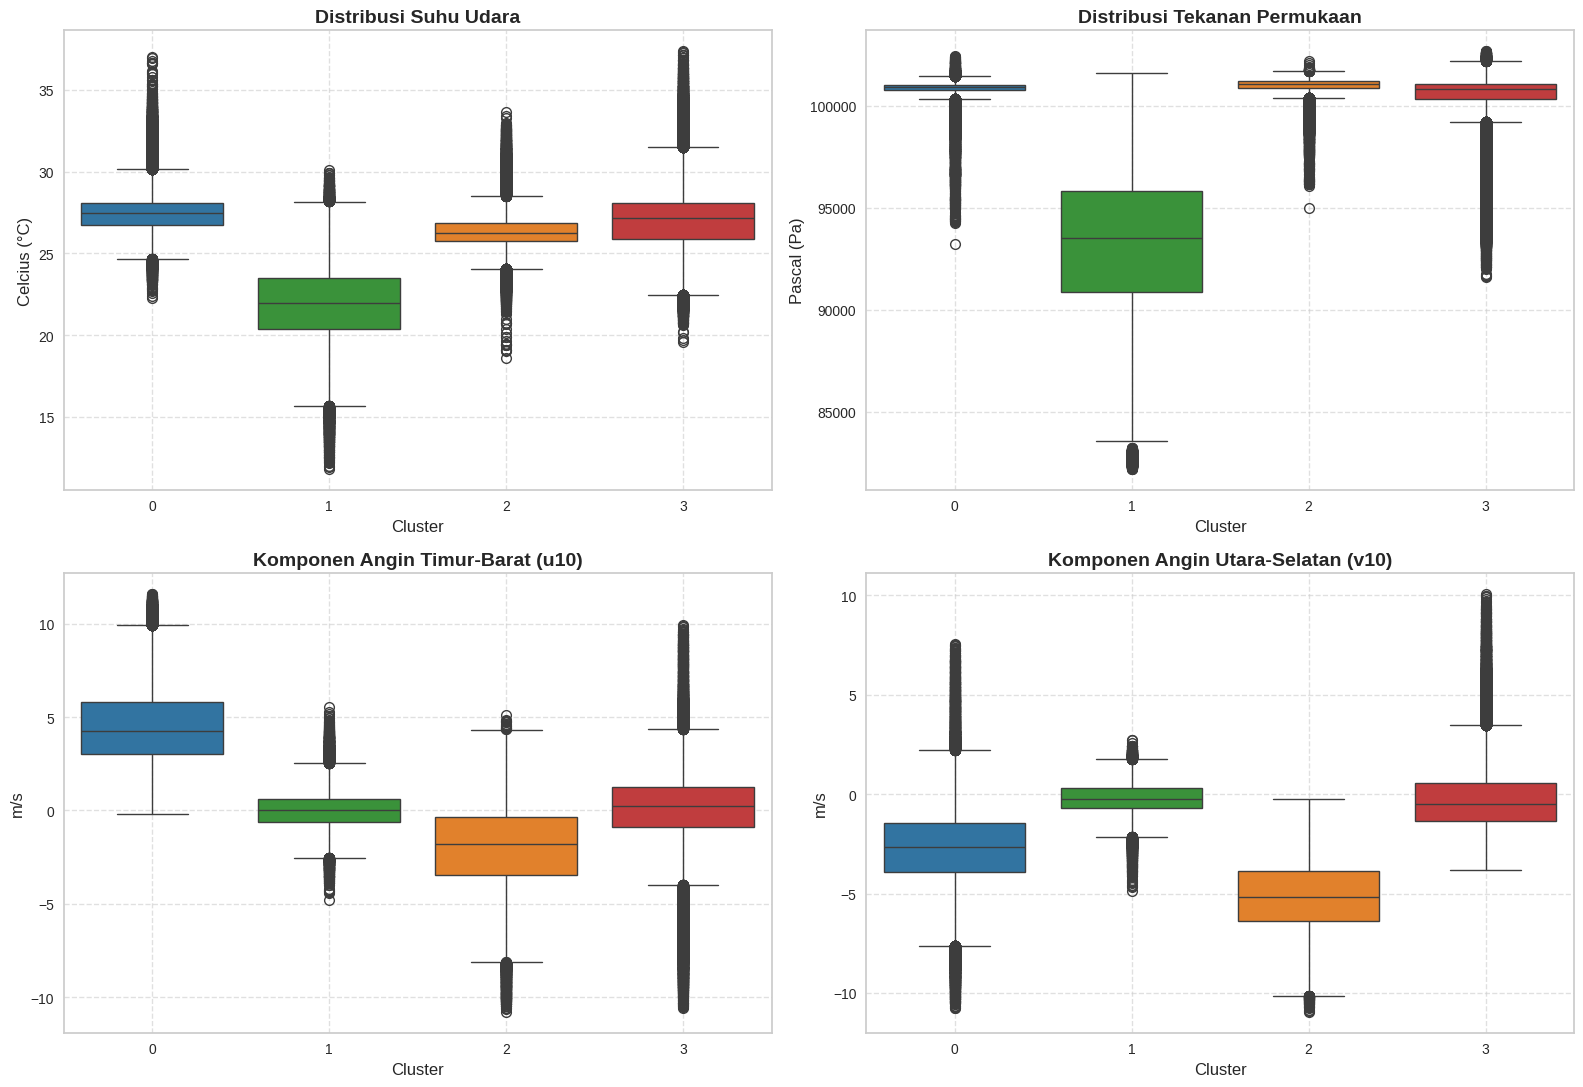

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure t2m_celcius is present in df_unscaled
if 't2m_celcius' not in df_unscaled.columns:
    df_unscaled['t2m_celcius'] = df_unscaled['t2m'] - 273.15

# 1. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the features and their corresponding labels
features = [
    ('t2m_celcius', 'Distribusi Suhu Udara', 'Celcius (°C)'),
    ('sp', 'Distribusi Tekanan Permukaan', 'Pascal (Pa)'),
    ('u10', 'Komponen Angin Timur-Barat (u10)', 'm/s'),
    ('v10', 'Komponen Angin Utara-Selatan (v10)', 'm/s')
]

# 3-5. Create boxplots for each feature with standardized palette
for i, (col, title, ylabel) in enumerate(features):
    ax = axes[i // 2, i % 2]
    sns.boxplot(
        ax=ax,
        x='cluster',
        y=col,
        data=df_unscaled,
        hue='cluster',
        palette=cluster_palette,
        legend=False
    )
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

# 6. Adjust layout and save
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

statistik deskriptif lengkap (rata-rata, simpangan baku, nilai minimum, nilai maksimum, dll.) untuk setiap kluster yang teridentifikasi dengan menggunakan fitur cuaca yang belum diskalakan.

In [ ]:
# Select weather features and cluster labels for descriptive analysis
features_to_analyze = ['t2m_celcius', 'sp', 'u10', 'v10']

# Group by cluster and calculate descriptive statistics
cluster_descriptive_stats = df_unscaled.groupby('cluster')[features_to_analyze].describe()

# Display the statistics table
print("Descriptive Statistics per Cluster (Unscaled Features):")
import pandas as pd
pd.set_option('display.max_columns', None)
display(cluster_descriptive_stats)

Descriptive Statistics per Cluster (Unscaled Features):


t2m_celcius                                                     \
              count       mean       std       min       25%       50%   
cluster                                                                  
0          453365.0  27.462852  1.090015  22.29580  26.70693  27.44840   
1          138868.0  21.947776  2.485460  11.81753  20.35830  21.98696   
2          281928.0  26.351579  0.968030  18.61587  25.73257  26.24612   
3          673455.0  27.038315  1.879736  19.59854  25.84976  27.18180   

                                   sp                                         \
              75%       max     count           mean          std        min   
cluster                                                                        
0        28.07680  37.02993  453365.0  100881.425357   321.514296  93250.125   
1        23.48184  30.10952  138868.0   93058.054614  3432.694068  82209.810   
2        26.85220  33.65078  281928.0  101021.760722   320.826514  95004.810   
3        28.10513  37.35780  673455.0  100416.299764  1203.014530  91606.440   

                                                                 u10  \
                 25%          50%          75%         max     count   
cluster                                                                
0        100763.7500  100907.8100  101045.0000  102439.125  453365.0   
1         90894.1875   93510.6875   95835.3425  101598.000  138868.0   
2        100884.2500  101057.9400  101221.0000  102191.250  281928.0   
3        100337.1250  100844.3750  101086.1250  102683.940  673455.0   

                                                                      \
             mean       std        min       25%       50%       75%   
cluster                                                                
0        4.505580  1.944245  -0.200195  3.044144  4.267151  5.792511   
1        0.021770  0.929602  -4.773392 -0.633045 -0.004562  0.628132   
2       -1.973393  2.194929 -10.787888 -3.473247 -1.787910 -0.360535   
3        0.140966  1.758939 -10.581573 -0.868958  0.232742  1.228111   

                         v10                                           \
               max     count      mean       std        min       25%   
cluster                                                                 
0        11.577240  453365.0 -2.727814  1.865299 -10.744232 -3.936554   
1         5.560516  138868.0 -0.218354  0.721128  -4.871414 -0.692757   
2         5.129471  281928.0 -5.131562  1.598948 -10.951431 -6.365559   
3         9.925812  673455.0 -0.291224  1.486213  -3.796204 -1.355804   

                                        
              50%       75%        max  
cluster                                 
0       -2.678162 -1.471909   7.555023  
1       -0.235168  0.287159   2.735519  
2       -5.159248 -3.848934  -0.261002  
3       -0.485077  0.583359  10.060394

Rata-rata nilai fitur/cluster

In [ ]:
# Define the features for the summary table
summary_features = ['t2m_celcius', 'sp', 'u10', 'v10']

# Group by cluster and calculate the mean
cluster_means = df_unscaled.groupby('cluster')[summary_features].mean()

# Display the clean summary table
print("Mean Weather Profiles per Cluster:")
display(cluster_means)

Mean Weather Profiles per Cluster:


,t2m_celcius,sp,u10,v10
cluster,,,,
0,27.462852,100881.425357,4.505580,-2.727814
1,21.947776,93058.054614,0.021770,-0.218354
2,26.351579,101021.760722,-1.973393,-5.131562
3,27.038315,100416.299764,0.140966,-0.291224


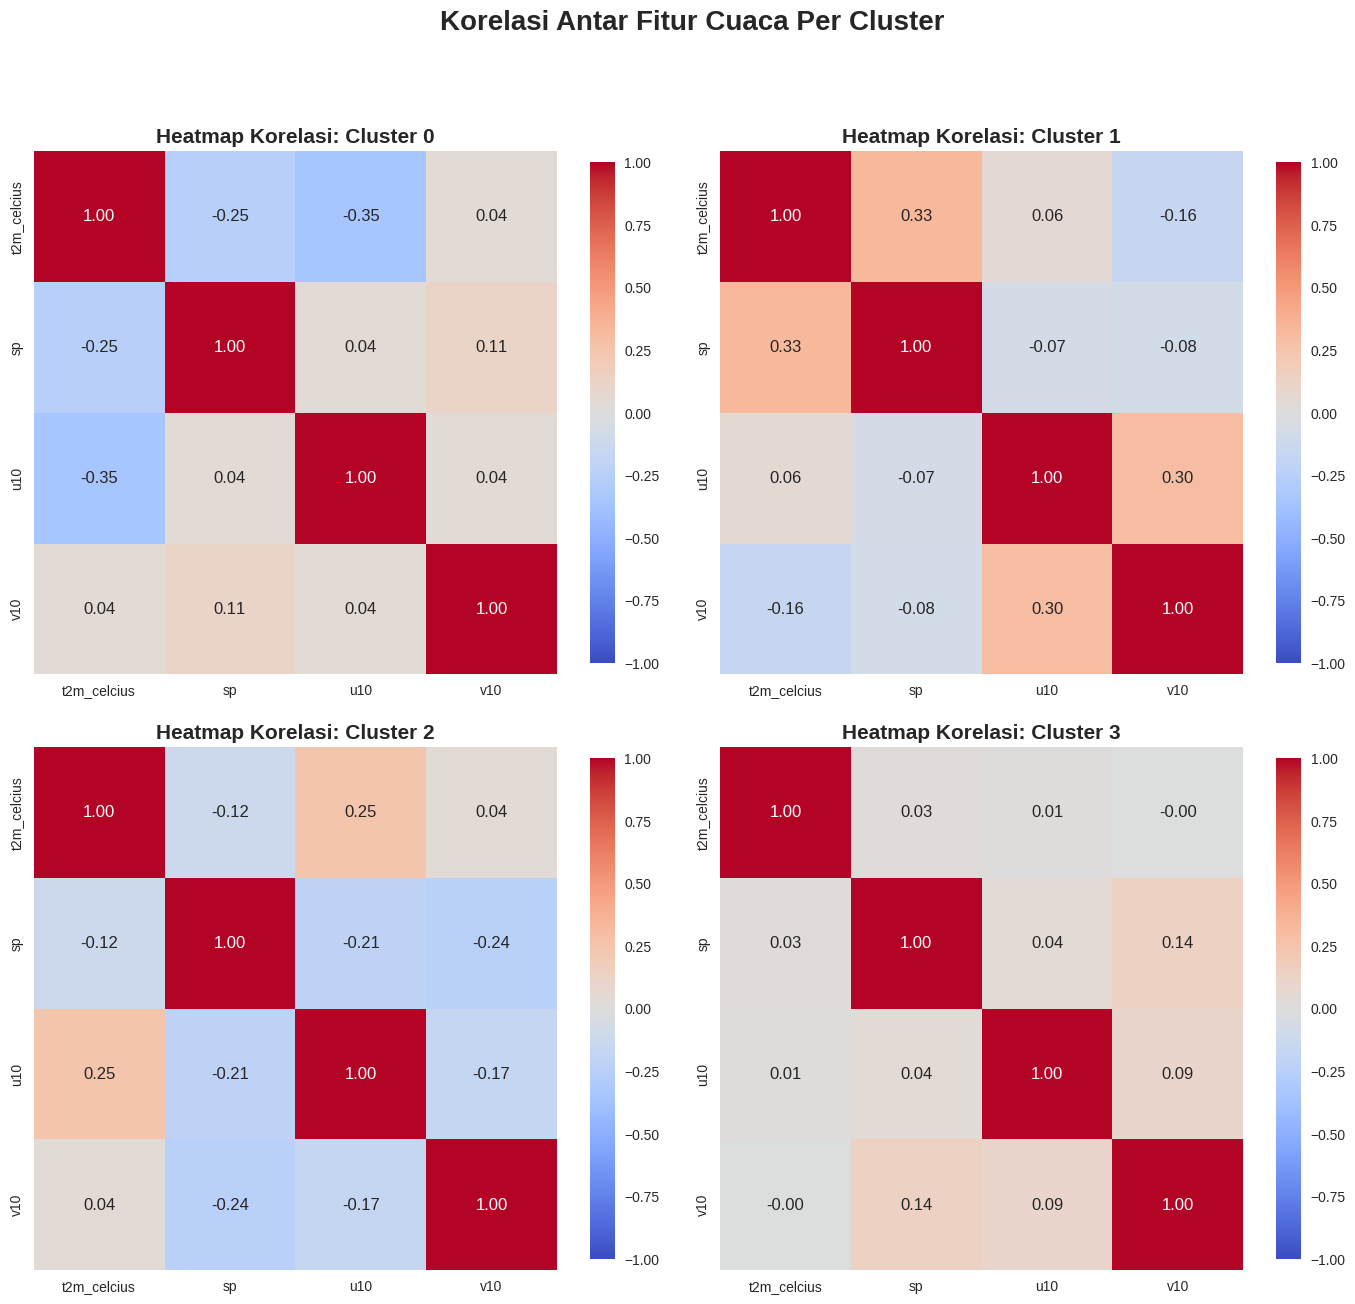

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define features to correlate
corr_features = ['t2m_celcius', 'sp', 'u10', 'v10']

# 2. Get unique cluster labels
clusters = sorted(df_unscaled['cluster'].unique())

# 3. Create a figure with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()
fig.suptitle('Korelasi Antar Fitur Cuaca Per Cluster', fontsize=20, fontweight='bold', y=0.95)

# 4-6. Iterate and plot heatmaps
for i, cluster_label in enumerate(clusters):
    # Filter data for the specific cluster
    cluster_data = df_unscaled[df_unscaled['cluster'] == cluster_label][corr_features]

    # Calculate Pearson correlation
    cluster_corr = cluster_data.corr()

    # Plot heatmap
    sns.heatmap(
        cluster_corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        ax=axes[i],
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={'shrink': .8}
    )

    axes[i].set_title(f'Heatmap Korelasi: Cluster {cluster_label}', fontsize=15, fontweight='bold')

# 7. Adjust layout and display
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()